### Week 02 Lab

In [1]:
import pandas as pd
import planetary_computer
import pystac_client
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np


from shapely.geometry import box
from odc.stac import configure_rio, stac_load
from dask.distributed import Client, LocalCluster
from IPython.display import Image

#### Part 1: Understand what data is available and how STAC organizes it.

In [2]:
## Connect to the Planetary Computer STAC catalog
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)
catalog.title

'Microsoft Planetary Computer STAC API'

In [3]:
## Find Landsat 8 Collection 2 Level 2 items for a specific date and location
all_collections = [i.id for i in catalog.get_collections()]
landsat_collections = [
    collection for collection in all_collections if "landsat" in collection
]
landsat_collections

['landsat-c2-l2', 'landsat-c2-l1']

In [4]:
## Explore the metadata
landsat_collection = catalog.get_collection("landsat-c2-l2")
landsat_collection

<CollectionClient id=landsat-c2-l2>

#### Part 2: Query for imagery over your study area and verify the results make sense

In [6]:
bbox = [103.70, 1.25, 103.90, 1.45]  # singapore bounding box (west, south, east, north)
datetime = "2025-01-01/2025-12-31"  # Full year of 2025
collection = "landsat-c2-l2"

In [ ]:
cluster = LocalCluster(
    processes=True,
    n_workers=8,
    threads_per_worker=2,
    memory_limit="6GB",
)
client = Client(cluster)
configure_rio(cloud_defaults=True, client=client)

In [7]:
search = catalog.search(
    bbox=bbox,
    datetime=datetime,
    collections=collection,
    query={"eo:cloud_cover": {"lt": 40}},
)

items = search.item_collection()

In [8]:
print(f"Returned {len(items)} Items:")
item_id = {(i, item.id): i for i, item in enumerate(items)}
item_id

Returned 20 Items:


{(0, 'LC08_L2SP_125059_20251205_02_T1'): 0,
 (1, 'LC09_L2SP_125059_20251026_02_T1'): 1,
 (2, 'LC08_L2SP_125059_20251018_02_T1'): 2,
 (3, 'LC08_L2SP_125059_20251002_02_T1'): 3,
 (4, 'LC09_L2SP_125059_20250924_02_T1'): 4,
 (5, 'LC08_L2SP_125059_20250831_02_T1'): 5,
 (6, 'LC08_L2SP_125059_20250815_02_T1'): 6,
 (7, 'LC09_L2SP_125059_20250807_02_T1'): 7,
 (8, 'LC08_L2SP_125059_20250730_02_T1'): 8,
 (9, 'LC09_L2SP_125059_20250706_02_T1'): 9,
 (10, 'LC09_L2SP_125059_20250604_02_T1'): 10,
 (11, 'LC08_L2SP_125059_20250527_02_T1'): 11,
 (12, 'LC08_L2SP_125059_20250511_02_T1'): 12,
 (13, 'LC09_L2SP_125059_20250503_02_T1'): 13,
 (14, 'LC08_L2SP_125059_20250425_02_T1'): 14,
 (15, 'LC08_L2SP_125059_20250409_02_T1'): 15,
 (16, 'LC09_L2SP_125059_20250401_02_T1'): 16,
 (17, 'LC08_L2SP_125059_20250308_02_T1'): 17,
 (18, 'LC09_L2SP_125059_20250127_02_T2'): 18,
 (19, 'LC08_L2SP_125059_20250103_02_T1'): 19}

In [26]:
selected_item = items[9]
selected_item

<Item id=LC09_L2SP_125059_20250706_02_T1>

In [27]:
selected_item.assets

{'qa': <Asset href=https://landsateuwest.blob.core.windows.net/landsat-c2/level-2/standard/oli-tirs/2025/125/059/LC09_L2SP_125059_20250706_20250707_02_T1/LC09_L2SP_125059_20250706_20250707_02_T1_ST_QA.TIF?st=2026-01-21T15%3A35%3A58Z&se=2026-01-22T16%3A20%3A58Z&sp=rl&sv=2025-07-05&sr=c&skoid=9c8ff44a-6a2c-4dfb-b298-1c9212f64d9a&sktid=72f988bf-86f1-41af-91ab-2d7cd011db47&skt=2026-01-22T06%3A43%3A58Z&ske=2026-01-29T06%3A43%3A58Z&sks=b&skv=2025-07-05&sig=n3%2BsGBKXPbeXCOYRUdawgHJbKAj/Yyjpiul0CCCzX0I%3D>,
 'ang': <Asset href=https://landsateuwest.blob.core.windows.net/landsat-c2/level-2/standard/oli-tirs/2025/125/059/LC09_L2SP_125059_20250706_20250707_02_T1/LC09_L2SP_125059_20250706_20250707_02_T1_ANG.txt?st=2026-01-21T15%3A35%3A58Z&se=2026-01-22T16%3A20%3A58Z&sp=rl&sv=2025-07-05&sr=c&skoid=9c8ff44a-6a2c-4dfb-b298-1c9212f64d9a&sktid=72f988bf-86f1-41af-91ab-2d7cd011db47&skt=2026-01-22T06%3A43%3A58Z&ske=2026-01-29T06%3A43%3A58Z&sks=b&skv=2025-07-05&sig=n3%2BsGBKXPbeXCOYRUdawgHJbKAj/Yyjpiul0CC

In [28]:
Image(url=selected_item.assets["rendered_preview"].href)

In [24]:
df = gpd.GeoDataFrame.from_features(items.to_dict(), crs="epsg:4326")

bbox_geom = box(*bbox)
bbox_gdf = gpd.GeoDataFrame([{"geometry": bbox_geom}], crs="epsg:4326")

# Create map with footprints
m = df[["geometry", "datetime", "eo:cloud_cover"]].explore(
    column="eo:cloud_cover", style_kwds={"fillOpacity": 0.1}
)

# Add bbox polygon on top
bbox_gdf.explore(m=m, style_kwds={"color": "red", "weight": 4, "fillOpacity": 0}, name="Bounding Box")

m

<Axes: title={'center': 'eo:cloud-cover'}, xlabel='datetime'>

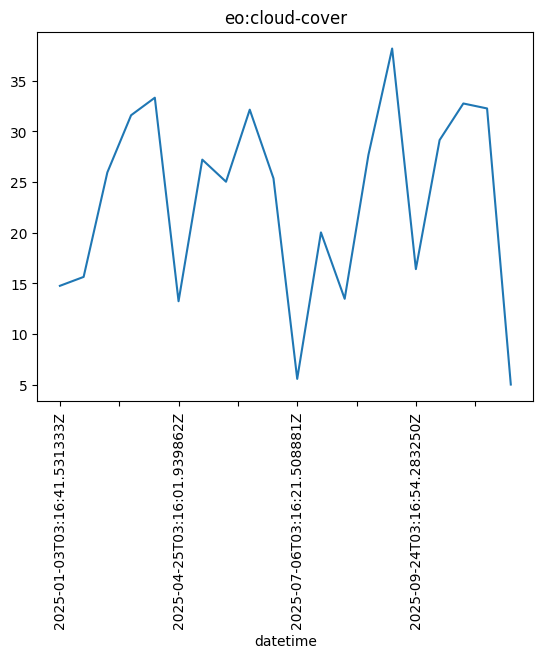

In [25]:
ts = df.set_index("datetime").sort_index()["eo:cloud_cover"]
ts.plot(title="eo:cloud-cover", rot=90)

#### Part 3: Combine multiple scenes into a single cloud-free image.

In [29]:
# Load data including qa_pixel
data = stac_load(
    items,
    bands=["nir08", "red", "green", "blue", "qa_pixel"],
    crs="EPSG:3857",
    resolution=30,
    chunks={"time": -1, "x": 128, "y": 128},
    bbox=bbox,
)

In [30]:
data

<xarray.Dataset> Size: 111MB
Dimensions:      (y: 744, x: 743, time: 20)
Coordinates:
  * y            (y) float64 6kB 1.614e+05 1.614e+05 ... 1.392e+05 1.392e+05
  * x            (x) float64 6kB 1.154e+07 1.154e+07 ... 1.157e+07 1.157e+07
  * time         (time) datetime64[ns] 160B 2025-01-03T03:16:41.531333 ... 20...
    spatial_ref  int32 4B 3857
Data variables:
    nir08        (time, y, x) uint16 22MB dask.array<chunksize=(20, 128, 128), meta=np.ndarray>
    red          (time, y, x) uint16 22MB dask.array<chunksize=(20, 128, 128), meta=np.ndarray>
    green        (time, y, x) uint16 22MB dask.array<chunksize=(20, 128, 128), meta=np.ndarray>
    blue         (time, y, x) uint16 22MB dask.array<chunksize=(20, 128, 128), meta=np.ndarray>
    qa_pixel     (time, y, x) uint16 22MB dask.array<chunksize=(20, 128, 128), meta=np.ndarray>

In [31]:
total_bytes = sum(data[var].nbytes for var in data.data_vars)
print(f"Total size: {total_bytes / 1e9:.2f} GB ({total_bytes / 1e6:.2f} MB)")

Total size: 0.11 GB (110.56 MB)


In [32]:
print(f"CRS: {data.spatial_ref.spatial_ref}")
print(f"Spatial ref attrs: {data.spatial_ref.attrs}")

CRS: <xarray.DataArray 'spatial_ref' ()> Size: 4B
array(3857, dtype=int32)
Coordinates:
    spatial_ref  int32 4B 3857
Attributes:
    spatial_ref:   PROJCRS["WGS 84 / Pseudo-Mercator",BASEGEOGCRS["WGS 84",EN...
    crs_wkt:       PROJCRS["WGS 84 / Pseudo-Mercator",BASEGEOGCRS["WGS 84",EN...
    GeoTransform:  11543820 30 0 161460 0 -30
Spatial ref attrs: {'spatial_ref': 'PROJCRS["WGS 84 / Pseudo-Mercator",BASEGEOGCRS["WGS 84",ENSEMBLE["World Geodetic System 1984 ensemble",MEMBER["World Geodetic System 1984 (Transit)"],MEMBER["World Geodetic System 1984 (G730)"],MEMBER["World Geodetic System 1984 (G873)"],MEMBER["World Geodetic System 1984 (G1150)"],MEMBER["World Geodetic System 1984 (G1674)"],MEMBER["World Geodetic System 1984 (G1762)"],MEMBER["World Geodetic System 1984 (G2139)"],MEMBER["World Geodetic System 1984 (G2296)"],ELLIPSOID["WGS 84",6378137,298.257223563,LENGTHUNIT["metre",1]],ENSEMBLEACCURACY[2.0]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],ID["EPSG",4326

In [33]:
# Create cloud mask from qa_pixel
# Bit 3 = cloud, Bit 4 = cloud shadow
# Mask is True where pixels are CLEAR
cloud_mask = (data["qa_pixel"] & 0b11000) == 0

# Apply mask to spectral bands (clouds become NaN)
data_masked = data[["nir08", "red", "green", "blue"]].where(cloud_mask)

# Median now ignores NaN (cloudy) pixels
median = data_masked.median(dim="time")
result = median.compute()

#### Part3

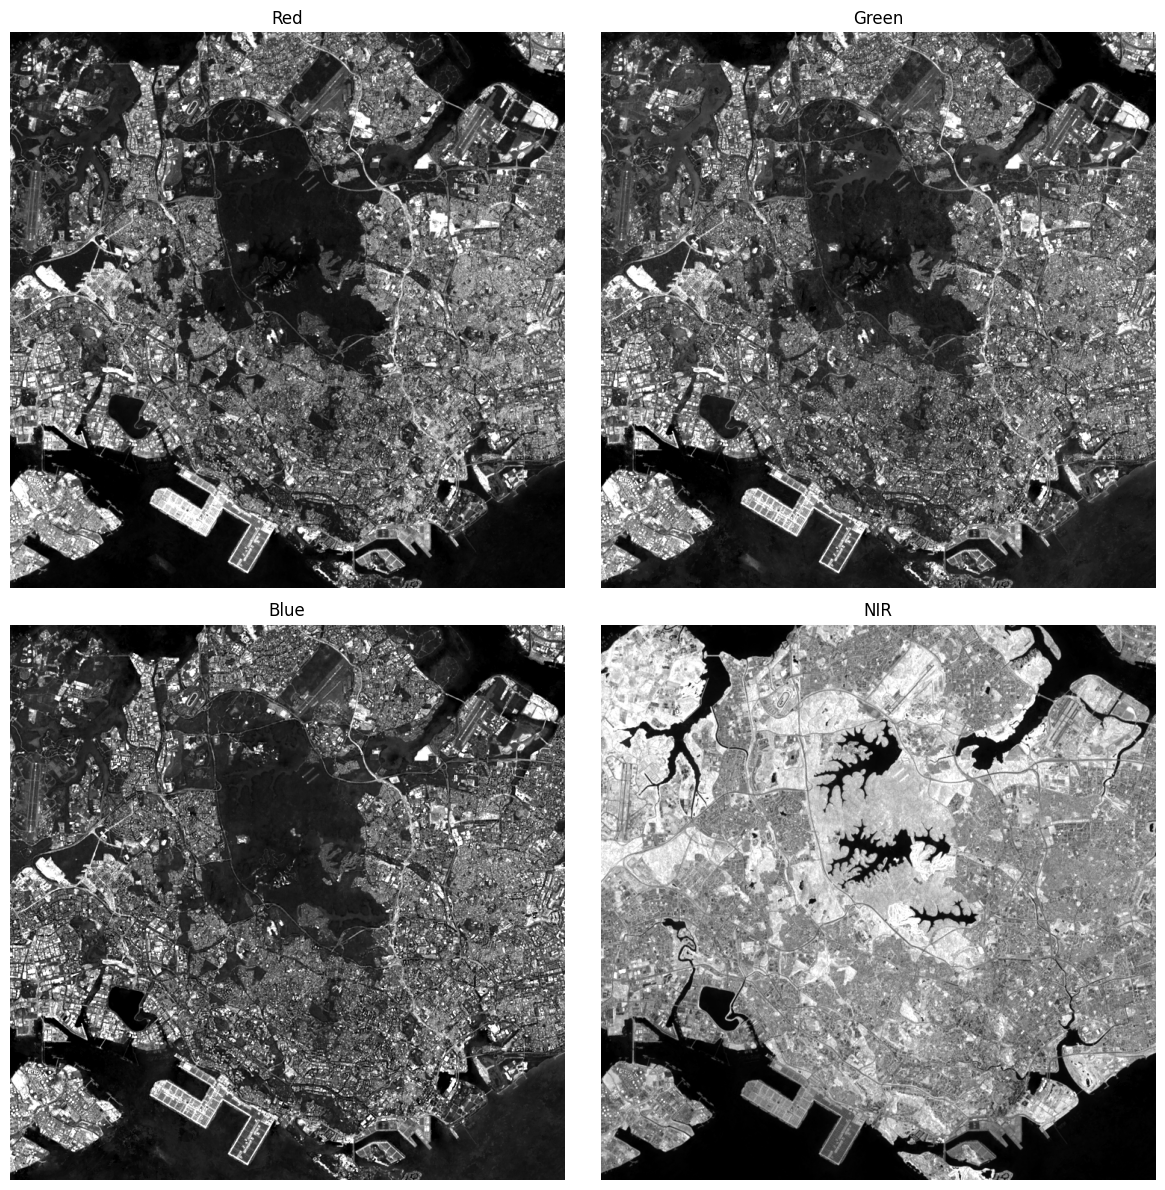

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

bands = ["red", "green", "blue", "nir08"]
band_names = ["Red", "Green", "Blue", "NIR"]

for ax, band, name in zip(axes.flat, bands, band_names):
    data = result[band].values

    # Normalize each band
    p2, p98 = np.nanpercentile(data, (2, 98))
    normalized = np.clip((data - p2) / (p98 - p2), 0, 1)

    ax.imshow(normalized, cmap="gray")
    ax.set_title(name)
    ax.axis("off")

plt.tight_layout()
plt.show()

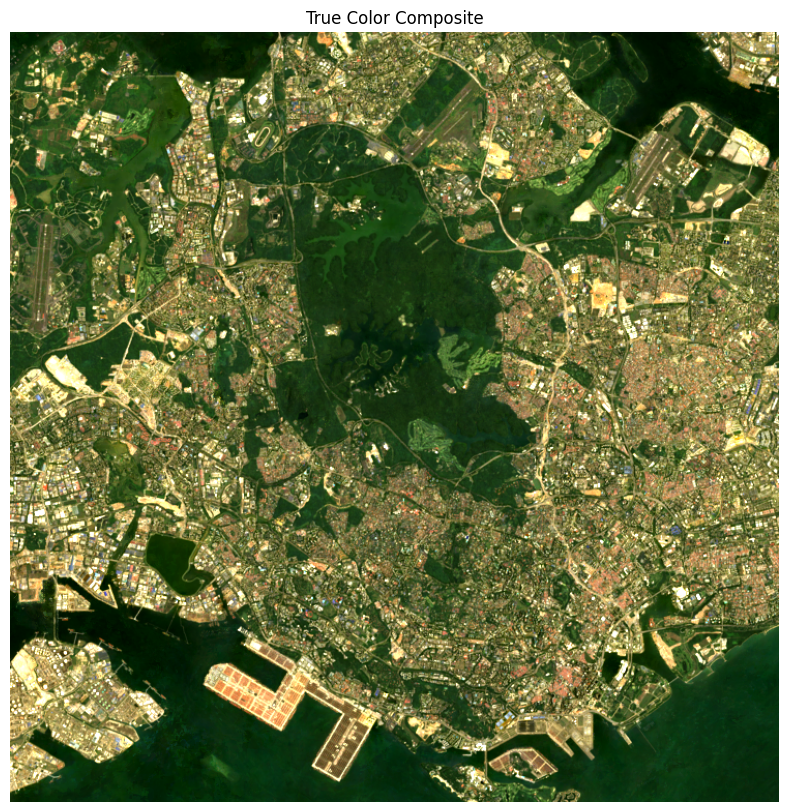

In [35]:
# Stack bands as RGB - access as dataset variables
rgb = np.stack(
    [result["red"].values, result["green"].values, result["blue"].values], axis=-1
)

# Normalize to 0-1 range
p2, p98 = np.nanpercentile(rgb, (2, 98))
rgb_normalized = np.clip((rgb - p2) / (p98 - p2), 0, 1)

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(rgb_normalized)
ax.set_title("True Color Composite")
ax.axis("off")
plt.show()

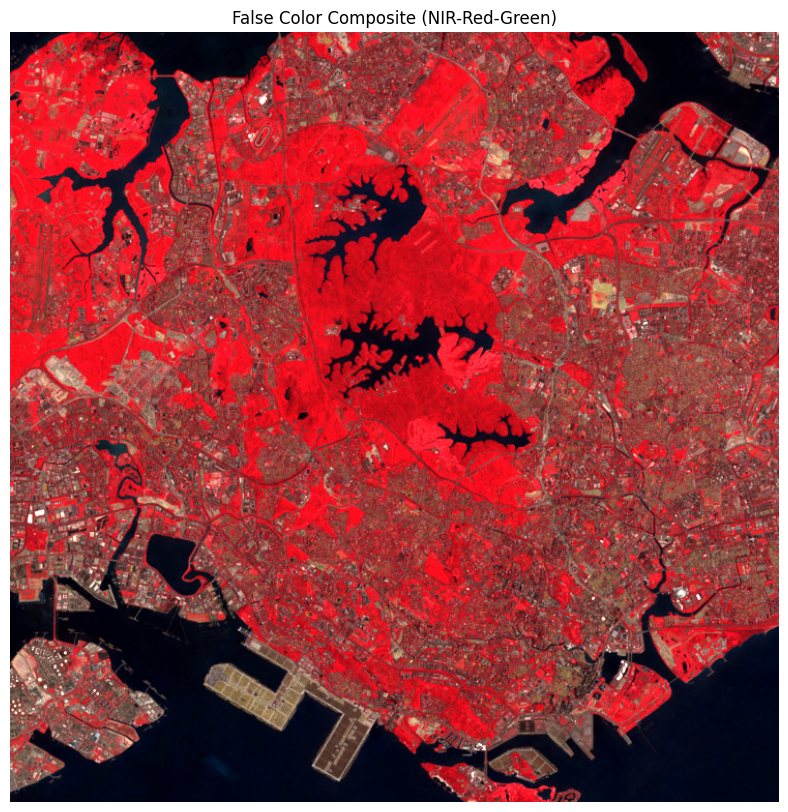

In [36]:
# Stack bands as NIR-Red-Green (false color)
false_color = np.stack(
    [result["nir08"].values, result["red"].values, result["green"].values], axis=-1
)

# Normalize to 0-1 range (adjust percentiles to taste)
p2, p98 = np.nanpercentile(false_color, (2, 98))
fc_normalized = np.clip((false_color - p2) / (p98 - p2), 0, 1)

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(fc_normalized)
ax.set_title("False Color Composite (NIR-Red-Green)")
ax.axis("off")
plt.show()